# Full NIST Binary Surface Tension Prediction

This notebook is a standalone AMS Python example for fitting binary liquid surface tension on the full neutral-binary subset of the NIST data package at [10.18434/mds2-2962](https://doi.org/10.18434/mds2-2962).

It uses:
- the bundled raw NIST files for provenance and inspection
- the bundled curated regression table `nist_binary_surface_tension_curated.csv`
- `RDKit` descriptors
- `SG1` FastSigma sigma moments
- `PropPred` pure-compound properties, with experimental fallback values for water

The fit is intentionally light enough to run on a fresh AMS installation without any precomputed feature caches or saved model weights.


## Requirements

Run this notebook in the AMS Python environment.

`SG1` may need to be installed first:

```bash
"$AMSBIN"/amspackages install molsg_sg1db
```

The notebook is self-contained and only expects the packaged `data/raw` and `data/processed` folders to be present next to it.


In [1]:
from __future__ import annotations

from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from pyCRS import FastSigma, Input, PropPred
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline

DEFAULT_PROJECT_ROOT = Path("/Users/fedor/Documents/EvonikPackage/binary_mixture_surface_tension_full_nist_standalone")
candidate_roots = [Path.cwd(), DEFAULT_PROJECT_ROOT, Path.cwd().parent]
ROOT = None
for candidate in candidate_roots:
    if (candidate / "data" / "processed" / "nist_binary_surface_tension_curated.csv").exists():
        ROOT = candidate.resolve()
        break
if ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/nist_binary_surface_tension_curated.csv. "
        "Set DEFAULT_PROJECT_ROOT in this cell to the notebook project directory."
    )

DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CURATED_PATH = PROCESSED_DIR / "nist_binary_surface_tension_curated.csv"
COMPOUNDS_PATH = PROCESSED_DIR / "nist_compounds_curated.csv"
RAW_SURFTEN_PATH = RAW_DIR / "surften.dat"
RAW_REFS_PATH = RAW_DIR / "refs.dat"
RAW_COMPOUNDS_PATH = RAW_DIR / "compounds.sdf"
NIST_URL = "https://doi.org/10.18434/mds2-2962"
WATER_SMILES = "O"
RANDOM_STATE = 7

WATER_PROPERTY_TABLE = pd.DataFrame(
    {
        "T_K": [293.15, 303.15, 313.15, 323.15, 333.15, 343.15, 353.15, 363.15, 373.15, 383.15, 393.15, 403.15],
        "visc_Pa_s": [1.002e-3, 0.7975e-3, 0.6531e-3, 0.5465e-3, 0.4660e-3, 0.4040e-3, 0.3550e-3, 0.3150e-3, 0.2820e-3, 0.2550e-3, 0.2320e-3, 0.2130e-3],
        "density_kg_L": [0.9982, 0.9957, 0.9922, 0.9880, 0.9832, 0.9778, 0.9718, 0.9653, 0.9584, 0.9510, 0.9432, 0.9350],
        "vaporpressure_bar": [0.0234, 0.0424, 0.0738, 0.1235, 0.1990, 0.3109, 0.4727, 0.7011, 1.0133, 1.4290, 1.9710, 2.6630],
    }
)
WATER_SURFTEN_TABLE = pd.DataFrame(
    {
        "T_K": [293.15, 298.15, 303.15, 308.15, 313.15, 318.15, 323.15],
        "surften_N_m": [0.07250, 0.07190, 0.07117, 0.07038, 0.069455, 0.06883, 0.06792],
    }
)
SIGMA_GRID = np.linspace(-0.025, 0.025, 51)
HB_LEVELS = [1, 2, 3, 4]
HB_CUTOFFS = {1: 0.00854, 2: 0.010, 3: 0.012, 4: 0.014}


In [2]:
from __future__ import annotations

print("Project root:", ROOT)
print("NIST source:", NIST_URL)
print("Raw surface tension file exists:", RAW_SURFTEN_PATH.exists())
print("Curated regression table exists:", CURATED_PATH.exists())


Project root: C:\Users\carstensen\Downloads\binary_mixture_surface_tension_standalone\binary_mixture_surface_tension_standalone
NIST source: https://doi.org/10.18434/mds2-2962
Raw surface tension file exists: True
Curated regression table exists: True


## Helpers

The next cell defines the descriptor builders, SG1 sigma-moment extraction, pure-property fallback handling for water, and the grouped holdout fit utilities used later in the notebook.


In [3]:
from __future__ import annotations

def canonical_smiles(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Could not parse SMILES: {smiles}")
    return Chem.MolToSmiles(mol)


def water_fallback_properties(temperature: float) -> dict[str, float]:
    tgrid = WATER_PROPERTY_TABLE["T_K"].to_numpy()
    return {
        "prop_liquidviscosity_Pa_s": float(np.interp(temperature, tgrid, WATER_PROPERTY_TABLE["visc_Pa_s"].to_numpy())),
        "prop_density_kg_L": float(np.interp(temperature, tgrid, WATER_PROPERTY_TABLE["density_kg_L"].to_numpy())),
        "prop_vaporpressure_bar": float(np.interp(temperature, tgrid, WATER_PROPERTY_TABLE["vaporpressure_bar"].to_numpy())),
        "prop_boilingpoint_K": 373.15,
    }


def water_surface_tension_mN_m(temperature: float) -> float:
    tgrid = WATER_SURFTEN_TABLE["T_K"].to_numpy()
    values = 1000.0 * WATER_SURFTEN_TABLE["surften_N_m"].to_numpy()
    return float(np.interp(float(temperature), tgrid, values))


def sigma_moments_from_profile(total_profile, hb_profile, prefix: str) -> dict[str, float]:
    total = np.asarray(list(total_profile), dtype=float)
    hb = np.asarray(list(hb_profile), dtype=float)
    out = {}
    for power in range(7):
        out[f"{prefix}_mom{power}"] = float(np.trapz(total * (SIGMA_GRID**power), SIGMA_GRID))
    for level in HB_LEVELS:
        cutoff = HB_CUTOFFS[level]
        out[f"{prefix}_hb_acc{level}"] = float(np.trapz(hb * np.maximum(0.0, SIGMA_GRID - cutoff), SIGMA_GRID))
        out[f"{prefix}_hb_don{level}"] = float(np.trapz(hb * np.maximum(0.0, -SIGMA_GRID - cutoff), SIGMA_GRID))
    return out


def sigma_descriptors(smiles: str) -> dict[str, float]:
    mol = Input.read_smiles(smiles)
    FastSigma.estimate(mol, method="COSMO-RS", model="SG1", display=False)
    sigma = mol.get_sigma_profile()
    out = {
        "sg1_area": float(mol.area),
        "sg1_volume": float(mol.volume),
        "sg1_molar_mass": float(mol.molar_mass),
    }
    out.update(sigma_moments_from_profile(sigma["Total Profile"], sigma["H-Bonding Profile"], "sg1"))
    return out


def rdkit_descriptors(smiles: str) -> dict[str, float]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Could not parse RDKit molecule: {smiles}")
    out = {}
    for name, func in Descriptors._descList:
        try:
            out[f"rdkit_{name}"] = float(func(mol))
        except Exception:
            out[f"rdkit_{name}"] = np.nan
    return out


def pure_properties(smiles: str, temperature: float) -> dict[str, float]:
    if canonical_smiles(smiles) == WATER_SMILES:
        return water_fallback_properties(float(temperature))
    mol = Input.read_smiles(smiles)
    PropPred.estimate(
        mol,
        properties=["liquidviscosity", "density", "vaporpressure", "boilingpoint"],
        temperatures=[round(float(temperature), 2)],
        show_errors=False,
    )
    _, vp_v = mol.get_tdep_values("vaporpressure")
    _, visc_v = mol.get_tdep_values("liquidviscosity")
    return {
        "prop_liquidviscosity_Pa_s": float(visc_v[0]) if visc_v else np.nan,
        "prop_density_kg_L": float(mol.properties.get("density", np.nan)),
        "prop_vaporpressure_bar": float(vp_v[0]) if vp_v else np.nan,
        "prop_boilingpoint_K": float(mol.properties.get("boilingpoint", np.nan)),
    }


def component_feature_block(left: dict[str, float], right: dict[str, float], x_left: float, x_right: float, prefix: str) -> dict[str, float]:
    out = {}
    shared = sorted(set(left) & set(right))
    for key in shared:
        out[f"{prefix}_comp1_{key}"] = float(left[key])
        out[f"{prefix}_comp2_{key}"] = float(right[key])
        out[f"{prefix}_avg_{key}"] = float(x_left * left[key] + x_right * right[key])
        out[f"{prefix}_diff_{key}"] = float(abs(left[key] - right[key]))
    return out


def sanitize_frame(df: pd.DataFrame, clip: float = 1e6) -> pd.DataFrame:
    clean = df.copy()
    numeric_cols = clean.select_dtypes(include=[np.number]).columns
    clean[numeric_cols] = clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
    clean[numeric_cols] = clean[numeric_cols].clip(lower=-clip, upper=clip)
    return clean


def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(a, b)))


def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.nan_to_num(y_pred, nan=np.nanmedian(y_true), posinf=np.nanmax(y_true), neginf=np.nanmin(y_true))
    y_pred = np.clip(y_pred, 1e-8, None)
    return {
        "R2_mN_m": float(r2_score(y_true, y_pred)),
        "MAE_mN_m": float(mean_absolute_error(y_true, y_pred)),
        "RMSE_mN_m": rmse(y_true, y_pred),
        "R2_log": float(r2_score(np.log(y_true), np.log(y_pred))),
        "RMSE_log": rmse(np.log(y_true), np.log(y_pred)),
    }


def make_full_binary_set(curated_df: pd.DataFrame) -> pd.DataFrame:
    df = curated_df[curated_df["is_neutral_single_species_pair"]].copy().reset_index(drop=True)
    left_first = df["canonical_smiles1"] <= df["canonical_smiles2"]
    df["comp1_smiles"] = np.where(left_first, df["canonical_smiles1"], df["canonical_smiles2"])
    df["comp2_smiles"] = np.where(left_first, df["canonical_smiles2"], df["canonical_smiles1"])
    df["comp1_label"] = np.where(left_first, df["label1"], df["label2"])
    df["comp2_label"] = np.where(left_first, df["label2"], df["label1"])
    df["x_comp1"] = np.where(left_first, df["x1"], 1.0 - df["x1"])
    df["x_comp2"] = 1.0 - df["x_comp1"]
    df["binary_label"] = df["comp1_label"].astype(str) + " + " + df["comp2_label"].astype(str)
    return df


def filter_sg1_supported(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    compounds = sorted(set(df["comp1_smiles"].dropna()) | set(df["comp2_smiles"].dropna()))
    supported = []
    failures = []
    for smiles in compounds:
        try:
            sigma_descriptors(smiles)
            supported.append(smiles)
        except Exception as exc:
            failures.append({"smiles": smiles, "reason": str(exc)})
    filtered = df[df["comp1_smiles"].isin(supported) & df["comp2_smiles"].isin(supported)].copy().reset_index(drop=True)
    return filtered, pd.DataFrame(failures)


def build_feature_table(df: pd.DataFrame) -> pd.DataFrame:
    smiles_set = sorted(set(df["comp1_smiles"].dropna()) | set(df["comp2_smiles"].dropna()))
    print(f"Building descriptors for {len(smiles_set)} unique compounds...")
    sigma_cache = {smiles: sigma_descriptors(smiles) for smiles in smiles_set}
    rdkit_cache = {smiles: rdkit_descriptors(smiles) for smiles in smiles_set}

    pair_temp_df = pd.concat(
        [
            df[["comp1_smiles", "T_K"]].rename(columns={"comp1_smiles": "smiles"}),
            df[["comp2_smiles", "T_K"]].rename(columns={"comp2_smiles": "smiles"}),
        ],
        ignore_index=True,
    ).drop_duplicates()
    pure_cache = {}
    print(f"Building PropPred / experimental pure-property table for {len(pair_temp_df)} compound-temperature combinations...")
    for idx, row in pair_temp_df.iterrows():
        if idx % 1000 == 0:
            print(f"  pure properties {idx}/{len(pair_temp_df)}")
        pure_cache[(row["smiles"], float(row["T_K"]))] = pure_properties(row["smiles"], float(row["T_K"]))

    rows = []
    nrows = len(df)
    for idx, row in df.iterrows():
        if idx % 5000 == 0:
            print(f"  assembling feature rows {idx}/{nrows}")
        t = float(row["T_K"])
        left_props = pure_cache[(row["comp1_smiles"], t)]
        right_props = pure_cache[(row["comp2_smiles"], t)]
        left_st = water_surface_tension_mN_m(t) if row["comp1_smiles"] == WATER_SMILES else 0.0
        right_st = water_surface_tension_mN_m(t) if row["comp2_smiles"] == WATER_SMILES else 0.0
        rec = {
            "pair_key": row["pair_key"],
            "binary_label": row["binary_label"],
            "comp1_smiles": row["comp1_smiles"],
            "comp2_smiles": row["comp2_smiles"],
            "x_comp1": row["x_comp1"],
            "x_comp2": row["x_comp2"],
            "x_mix": row["x_comp1"] * row["x_comp2"],
            "T_K": row["T_K"],
            "surften_mN_m": row["surften_mN_m"],
            "ref_id": row["ref_id"],
            "full_ref": row["full_ref"],
            "comp1_water_surface_tension_mN_m": left_st,
            "comp2_water_surface_tension_mN_m": right_st,
        }
        rec.update(component_feature_block(left_props, right_props, row["x_comp1"], row["x_comp2"], "pure"))
        rec.update(component_feature_block(sigma_cache[row["comp1_smiles"]], sigma_cache[row["comp2_smiles"]], row["x_comp1"], row["x_comp2"], "sg1"))
        rec.update(component_feature_block(rdkit_cache[row["comp1_smiles"]], rdkit_cache[row["comp2_smiles"]], row["x_comp1"], row["x_comp2"], "rdkit"))
        rows.append(rec)
    return pd.DataFrame(rows)


def prepare_feature_sets(feature_df: pd.DataFrame) -> tuple[dict[str, list[str]], pd.DataFrame]:
    base_cols = [
        "x_comp1",
        "x_comp2",
        "x_mix",
        "T_K",
        "pure_comp1_prop_liquidviscosity_Pa_s",
        "pure_comp2_prop_liquidviscosity_Pa_s",
        "pure_comp1_prop_density_kg_L",
        "pure_comp2_prop_density_kg_L",
        "pure_comp1_prop_vaporpressure_bar",
        "pure_comp2_prop_vaporpressure_bar",
        "pure_comp1_prop_boilingpoint_K",
        "pure_comp2_prop_boilingpoint_K",
        "pure_avg_prop_boilingpoint_K",
        "pure_diff_prop_boilingpoint_K",
        "comp1_water_surface_tension_mN_m",
        "comp2_water_surface_tension_mN_m",
    ]
    rdkit_cols = [c for c in feature_df.columns if c.startswith("rdkit_")]
    sg1_cols = [c for c in feature_df.columns if c.startswith("sg1_")]

    selector_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            (
                "model",
                ExtraTreesRegressor(
                    n_estimators=120,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    max_depth=16,
                    min_samples_leaf=10,
                    min_samples_split=20,
                ),
            ),
        ]
    )
    selector_pipe.fit(sanitize_frame(feature_df[rdkit_cols]), feature_df["surften_mN_m"])
    importance_df = pd.DataFrame(
        {"feature": rdkit_cols, "importance": selector_pipe.named_steps["model"].feature_importances_}
    ).sort_values("importance", ascending=False)
    top12 = importance_df.head(12)["feature"].tolist()

    feature_sets = {
        "rdkit_top12": base_cols + top12,
        "sg1_plus_proppred": base_cols + sg1_cols,
        "rdkit_top12_plus_sg1": base_cols + top12 + sg1_cols,
    }
    return feature_sets, importance_df


def create_parity_plot(train_df: pd.DataFrame, test_df: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(6.8, 6.0))
    obs = np.concatenate([train_df["surften_mN_m"].to_numpy(dtype=float), test_df["surften_mN_m"].to_numpy(dtype=float)])
    pred = np.concatenate([train_df["pred_surften_mN_m"].to_numpy(dtype=float), test_df["pred_surften_mN_m"].to_numpy(dtype=float)])
    lo = max(float(min(np.min(obs), np.min(pred))), 1e-3)
    hi = float(max(np.max(obs), np.max(pred)))
    ax.scatter(train_df["surften_mN_m"], train_df["pred_surften_mN_m"], s=8, alpha=0.35, edgecolors="none", color="#1f77b4", label="Train")
    ax.scatter(test_df["surften_mN_m"], test_df["pred_surften_mN_m"], s=8, alpha=0.55, edgecolors="none", color="#ff7f0e", label="Test")
    ax.plot([lo, hi], [lo, hi], color="#444444", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Observed surface tension (mN/m)")
    ax.set_ylabel("Predicted surface tension (mN/m)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.25)
    fig.tight_layout()
    return fig


## Load And Prepare Data

The raw `surften.dat` file is included for provenance. The regression workflow starts from the bundled curated table, then:

1. keeps neutral single-species binary systems,
2. canonicalizes component ordering,
3. removes compounds that SG1 cannot process,
4. builds pure-property, sigma-moment, and RDKit descriptor blocks.


In [4]:
from __future__ import annotations

curated_df = pd.read_csv(CURATED_PATH, low_memory=False)
raw_preview = pd.read_csv(RAW_SURFTEN_PATH, sep=r"\s+", comment="#", header=None, nrows=5)
print(f"Curated rows: {len(curated_df):,}")
print(f"Neutral binary rows in curated table: {int(curated_df['is_neutral_single_species_pair'].sum()):,}")
print(f"Unique raw pair keys in curated table: {curated_df['pair_key'].nunique():,}")
display(curated_df.head())
display(raw_preview)

full_df = make_full_binary_set(curated_df)
filtered_df, excluded_df = filter_sg1_supported(full_df)
print(f"Full neutral binary rows: {len(full_df):,}")
print(f"Rows after SG1 support filter: {len(filtered_df):,}")
print(f"Unique binary pairs after SG1 filter: {filtered_df['pair_key'].nunique():,}")
print(f"Excluded compounds: {len(excluded_df):,}")
if len(excluded_df):
    display(excluded_df.head(20))

feature_df = build_feature_table(filtered_df)
print(feature_df.shape)
display(feature_df.head())


Curated rows: 40,805
Neutral binary rows in curated table: 29,815
Unique raw pair keys in curated table: 1,489


,comp1_raw,comp2_raw,x1,T_K,surften_N_m,u_surften_N_m,ref_raw,comp1,comp2,ref_id,...,pair_key,is_neutral_single_species_pair,contains_water,contains_amine,water_amine_pair,amine_smiles,amine_label,x_amine,x_water,P_bar
0,trc4mit_514,trc4mit_1049,0.0000,298.15,0.03737,0.00022,trc4mitref_187,514,1049,trc4mitref_187,...,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,True,False,False,False,NaN,NaN,0.0000,NaN,1.01325
1,trc4mit_514,trc4mit_1049,0.0797,298.15,0.03685,0.00027,trc4mitref_187,514,1049,trc4mitref_187,...,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,True,False,False,False,NaN,NaN,0.0797,NaN,1.01325
2,trc4mit_514,trc4mit_1049,0.2784,298.15,0.03556,0.00040,trc4mitref_187,514,1049,trc4mitref_187,...,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,True,False,False,False,NaN,NaN,0.2784,NaN,1.01325
3,trc4mit_514,trc4mit_1049,0.4909,298.15,0.03394,0.00052,trc4mitref_187,514,1049,trc4mitref_187,...,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,True,False,False,False,NaN,NaN,0.4909,NaN,1.01325
4,trc4mit_514,trc4mit_1049,0.6320,298.15,0.03264,0.00059,trc4mitref_187,514,1049,trc4mitref_187,...,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,True,False,False,False,NaN,NaN,0.6320,NaN,1.01325


,0,1,2,3,4,5,6
0,trc4mit_514,trc4mit_1049,0.0000,298.15,0.03737,0.00022,trc4mitref_187
1,trc4mit_514,trc4mit_1049,0.0797,298.15,0.03685,0.00027,trc4mitref_187
2,trc4mit_514,trc4mit_1049,0.2784,298.15,0.03556,0.00040,trc4mitref_187
3,trc4mit_514,trc4mit_1049,0.4909,298.15,0.03394,0.00052,trc4mitref_187
4,trc4mit_514,trc4mit_1049,0.6320,298.15,0.03264,0.00059,trc4mitref_187


Full neutral binary rows: 29,815
Rows after SG1 support filter: 29,815
Unique binary pairs after SG1 filter: 967
Excluded compounds: 0
Building descriptors for 386 unique compounds...
Building PropPred / experimental pure-property table for 2817 compound-temperature combinations...
  pure properties 0/2817
  pure properties 11000/2817
  pure properties 19000/2817
  pure properties 27000/2817
  pure properties 58000/2817
  assembling feature rows 0/29815
  assembling feature rows 5000/29815
  assembling feature rows 10000/29815
  assembling feature rows 15000/29815
  assembling feature rows 20000/29815
  assembling feature rows 25000/29815
(29815, 561)


,pair_key,binary_label,comp1_smiles,comp2_smiles,x_comp1,x_comp2,x_mix,T_K,surften_mN_m,ref_id,...,rdkit_avg_rdkit_VSA_EState8,rdkit_diff_rdkit_VSA_EState8,rdkit_comp1_rdkit_VSA_EState9,rdkit_comp2_rdkit_VSA_EState9,rdkit_avg_rdkit_VSA_EState9,rdkit_diff_rdkit_VSA_EState9,rdkit_comp1_rdkit_qed,rdkit_comp2_rdkit_qed,rdkit_avg_rdkit_qed,rdkit_diff_rdkit_qed
0,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1 + c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1,c1ccccc1,1.0000,0.0000,0.000000,298.15,37.37,trc4mitref_187,...,0.0,0.0,35.333333,12.0,35.333333,23.333333,0.502155,0.442628,0.502155,0.059527
1,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1 + c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1,c1ccccc1,0.9203,0.0797,0.073348,298.15,36.85,trc4mitref_187,...,0.0,0.0,35.333333,12.0,33.473667,23.333333,0.502155,0.442628,0.497411,0.059527
2,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1 + c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1,c1ccccc1,0.7216,0.2784,0.200893,298.15,35.56,trc4mitref_187,...,0.0,0.0,35.333333,12.0,28.837333,23.333333,0.502155,0.442628,0.485583,0.059527
3,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1 + c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1,c1ccccc1,0.5091,0.4909,0.249917,298.15,33.94,trc4mitref_187,...,0.0,0.0,35.333333,12.0,23.879000,23.333333,0.502155,0.442628,0.472934,0.059527
4,c1ccc(CCCCCCCCc2ccccc2)cc1__c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1 + c1ccccc1,c1ccc(CCCCCCCCc2ccccc2)cc1,c1ccccc1,0.3680,0.6320,0.232576,298.15,32.64,trc4mitref_187,...,0.0,0.0,35.333333,12.0,20.586667,23.333333,0.502155,0.442628,0.464534,0.059527


## Light Benchmark

This fit uses a grouped holdout split by `pair_key`, so the test set contains binary pairs not seen during training.


,feature,importance
198,rdkit_avg_rdkit_NHOHCount,0.163748
166,rdkit_avg_rdkit_MaxPartialCharge,0.077139
142,rdkit_avg_rdkit_Kappa2,0.069638
186,rdkit_avg_rdkit_MolLogP,0.066949
458,rdkit_avg_rdkit_qed,0.039717
2,rdkit_avg_rdkit_BalabanJ,0.039624
174,rdkit_avg_rdkit_MinAbsPartialCharge,0.032370
118,rdkit_avg_rdkit_FractionCSP3,0.023020
414,rdkit_avg_rdkit_TPSA,0.019320
394,rdkit_avg_rdkit_SlogP_VSA5,0.019163


Train rows: 24,079 across 773 pairs | Test rows: 5,736 across 194 pairs
Fitting rdkit_top12 with ExtraTrees...
Fitting sg1_plus_proppred with ExtraTrees...
Fitting rdkit_top12_plus_sg1 with ExtraTrees...


,feature_set,model,n_features,train_R2_mN_m,train_MAE_mN_m,train_RMSE_mN_m,train_R2_log,train_RMSE_log,test_R2_mN_m,test_MAE_mN_m,test_RMSE_mN_m,test_R2_log,test_RMSE_log
0,rdkit_top12_plus_sg1,extra_trees_light,100,0.913209,0.744187,4.508977,0.977395,0.073814,0.948135,1.891097,3.286327,0.905431,0.145782
1,sg1_plus_proppred,extra_trees_light,88,0.912107,0.766301,4.537502,0.978895,0.071323,0.943310,1.986855,3.435792,0.897644,0.151665
2,rdkit_top12,extra_trees_light,28,0.907426,0.935255,4.656786,0.967077,0.089081,0.929968,2.134006,3.818745,0.890006,0.157222


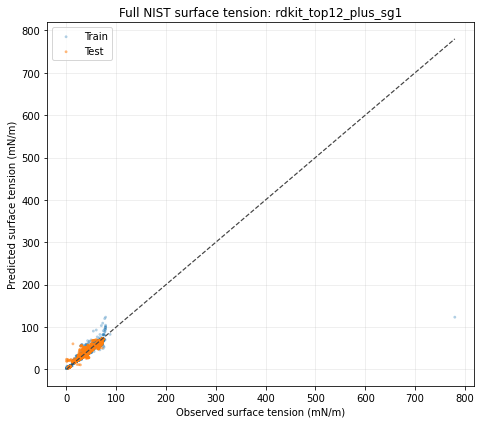

{
  "rows": 29815,
  "pairs": 967,
  "train_rows": 24079,
  "test_rows": 5736,
  "train_pairs": 773,
  "test_pairs": 194,
  "best_by_metric": {
    "feature_set": "rdkit_top12_plus_sg1",
    "model": "extra_trees_light",
    "n_features": 100,
    "train_R2_mN_m": 0.9132090114592492,
    "train_MAE_mN_m": 0.7441871131463184,
    "train_RMSE_mN_m": 4.508977234351603,
    "train_R2_log": 0.97739475009652,
    "train_RMSE_log": 0.0738139326769737,
    "test_R2_mN_m": 0.9481347745333842,
    "test_MAE_mN_m": 1.8910970227264108,
    "test_RMSE_mN_m": 3.2863268528124703,
    "test_R2_log": 0.9054313098638829,
    "test_RMSE_log": 0.14578160868666198
  }
}


In [5]:
from __future__ import annotations

feature_sets, importance_df = prepare_feature_sets(feature_df)
display(importance_df.head(20))

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(feature_df, groups=feature_df["pair_key"]))
train_df = feature_df.iloc[train_idx].reset_index(drop=True)
test_df = feature_df.iloc[test_idx].reset_index(drop=True)
print(
    f"Train rows: {len(train_df):,} across {train_df['pair_key'].nunique():,} pairs | "
    f"Test rows: {len(test_df):,} across {test_df['pair_key'].nunique():,} pairs"
)

model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            ExtraTreesRegressor(
                n_estimators=160,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                max_depth=16,
                min_samples_leaf=10,
                min_samples_split=20,
            ),
        ),
    ]
)

rows = []
all_preds = []
for feature_name, cols in feature_sets.items():
    print(f"Fitting {feature_name} with ExtraTrees...")
    X_train = sanitize_frame(train_df[cols])
    X_test = sanitize_frame(test_df[cols])
    y_train = train_df["surften_mN_m"].to_numpy()
    y_test = test_df["surften_mN_m"].to_numpy()
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    row = {"feature_set": feature_name, "model": "extra_trees_light", "n_features": len(cols)}
    row.update({f"train_{k}": v for k, v in metrics(y_train, train_pred).items()})
    row.update({f"test_{k}": v for k, v in metrics(y_test, test_pred).items()})
    rows.append(row)
    for split_name, split_df, split_pred in [("train", train_df, train_pred), ("test", test_df, test_pred)]:
        pred_df = split_df[["pair_key", "binary_label", "comp1_smiles", "comp2_smiles", "x_comp1", "T_K", "surften_mN_m"]].copy()
        pred_df["split"] = split_name
        pred_df["feature_set"] = feature_name
        pred_df["model"] = "extra_trees_light"
        pred_df["pred_surften_mN_m"] = split_pred
        all_preds.append(pred_df)

results_df = pd.DataFrame(rows).sort_values(["test_RMSE_mN_m", "test_RMSE_log"]).reset_index(drop=True)
preds_df = pd.concat(all_preds, ignore_index=True)
display(results_df)

best = results_df.iloc[0]
best_train = preds_df[
    (preds_df["feature_set"] == best["feature_set"]) & (preds_df["model"] == best["model"]) & (preds_df["split"] == "train")
].copy()
best_test = preds_df[
    (preds_df["feature_set"] == best["feature_set"]) & (preds_df["model"] == best["model"]) & (preds_df["split"] == "test")
].copy()
fig = create_parity_plot(best_train, best_test, f"Full NIST surface tension: {best['feature_set']}")
plt.show()

summary = {
    "rows": int(len(feature_df)),
    "pairs": int(feature_df["pair_key"].nunique()),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_pairs": int(train_df["pair_key"].nunique()),
    "test_pairs": int(test_df["pair_key"].nunique()),
    "best_by_metric": best.to_dict(),
}
print(json.dumps(summary, indent=2))


## Optional Save

Run the next cell if you want the results table, prediction table, parity plot, and summary written to the local `outputs/` folder.


In [6]:
from __future__ import annotations

results_df.to_csv(OUTPUT_DIR / "full_nist_surface_tension_light_results.csv", index=False)
preds_df.to_csv(OUTPUT_DIR / "full_nist_surface_tension_light_predictions.csv", index=False)
fig.savefig(OUTPUT_DIR / "full_nist_surface_tension_light_parity.png", dpi=180, bbox_inches="tight")
(OUTPUT_DIR / "full_nist_surface_tension_light_summary.json").write_text(json.dumps(summary, indent=2) + "\n")
if len(excluded_df):
    excluded_df.to_csv(OUTPUT_DIR / "full_nist_surface_tension_sg1_excluded_compounds.csv", index=False)
print("Wrote outputs to", OUTPUT_DIR)


Wrote outputs to C:\Users\carstensen\Downloads\binary_mixture_surface_tension_standalone\binary_mixture_surface_tension_standalone\outputs
